# Example: Estimating Single-Asset Geometric Brownian Motion Parameters
How do we translate an observed price history into the growth and volatility parameters used in the lecture? In this example, we will estimate the parameters of a geometric Brownian motion (GBM) model from historical share prices.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Estimate mean growth and volatility:** Fit a line to log prices, compare its slope with the sample mean of one-step growth rates, and use growth-rate dispersion to estimate volatility.
> * **Examine model assumptions:** Assess whether observed growth rates are consistent with independent normal observations, and explain why ordinary regression uncertainty formulas do not apply to Brownian log-price errors.
> * **Construct and interpret a fitted GBM model:** Recover arithmetic drift from mean growth and volatility, generate sample price paths, and compare lognormal price intervals with historical observations.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The dataset contains daily open-high-low-close (OHLC) records for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from 2014-01-03 through 2024-12-31, along with records for several exchange-traded funds and volatility products. In this example, we use the daily volume-weighted average price (VWAP), which weights transaction prices by the number of shares traded, as our observed share price.

Let's load the data using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We store the result in `original_dataset`, a dictionary whose keys are ticker symbols and whose values are `DataFrame` tables containing each ticker's price history.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers have the same number of price observations. For example, a firm may have been listed after the dataset begins or delisted before it ends. We will use `AAPL` as our reference and retain tickers with the same number of daily records.

First, let's count the records for `AAPL` and save that value in `maximum_number_trading_days::Int64`:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow;

Now, let's iterate through our data and collect tickers with `maximum_number_trading_days` records. We store the resulting dataset $\mathcal{D}$ in `dataset::Dict{String,DataFrame}`:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # Retain tickers with the same number of records as AAPL -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort; # list of firm "ticker" symbols in alphabetical order

### Constants
Let's set some constants that we'll use in this study. See the comment next to each constant for its definition and units.

In [6]:
Δt = (1.0/252.0); # time step in years: one trading day, assuming 252 trading days per year
T = 64; # daily steps in the Task 3 window: approximately one trading quarter, with T+1 price observations
all_range = range(1,stop=maximum_number_trading_days,step=1) |> collect; # price-observation row indices (unitless)
number_of_trend_simulations = 1000; # positive integer: number of perturbed trend fits (unitless)
trend_band_fraction = 0.95; # fraction of fitted prices in the pointwise band; between 0 and 1
regression_interval_level = 0.95; # nominal regression confidence level; between 0 and 1
number_of_paths = 100; # positive integer: number of simulated GBM price paths (unitless)
gbm_band_levels = [0.68, 0.95, 0.99]; # central pointwise price-band probabilities; each between 0 and 1

___

## Task 1: Estimate the mean growth rate $\mu_g$ from data
In this task, we estimate the mean growth rate $\mu_g$ for each firm in our dataset by fitting a line to its historical log prices. From the lecture, taking the logarithm of the geometric Brownian motion solution gives:

$$
\ln(S_{t_j})=\ln(S_0)+\mu_g t_j+\sigma W(t_j),
\qquad t_j=j\Delta t,\quad j=0,1,\ldots,N.
$$

The Wiener process has mean zero, so the expected log price is a straight line in time, with intercept $\ln(S_0)$ and slope $\mu_g$. We estimate these two parameters using least squares.

> __Interpreting the regression:__ The slope estimates mean growth, $\mu_g=\mu-\sigma^2/2$. After estimating volatility in Task 2, we recover the arithmetic drift using $\hat{\mu}=\hat{\mu}_g+\hat{\sigma}^2/2$. The Brownian errors are correlated across observation times, and their variance grows with time, so the usual regression uncertainty formulas do not apply. We examine this distinction in the optional diagnostic.

Let's collect the log-price observations and their observation times into a system of equations that we can solve for the intercept and slope.

Each of our $N+1$ log-price observations supplies an equation involving the intercept and slope. Collecting these equations gives:

$$
\hat{\mathbf X}\boldsymbol{\theta}+\epsilon=\mathbf y,
\qquad
\boldsymbol{\theta}=\begin{bmatrix}\ln(S_0)\\\mu_g\end{bmatrix},
$$

where $\epsilon$ contains the Brownian errors. The augmented design matrix $\hat{\mathbf X}$ contains a column of ones for the intercept and a column of observation times, while $\mathbf y$ contains the log prices:

$$
\hat{\mathbf X}=
\begin{bmatrix}
1&t_0\\
1&t_1\\
\vdots&\vdots\\
1&t_N
\end{bmatrix},
\qquad
\mathbf y=
\begin{bmatrix}
\ln(S_{t_0})\\
\ln(S_{t_1})\\
\vdots\\
\ln(S_{t_N})
\end{bmatrix}.
$$

Thus, $\hat{\mathbf X}$ has dimensions $(N+1)\times2$, and $\mathbf y$ has $N+1$ entries. The system is **overdetermined**: we have more observations than parameters. We choose the intercept and slope that minimize the sum of squared differences between observed and fitted log prices:

$$
\hat{\boldsymbol{\theta}}
=\underset{\boldsymbol{\theta}}{\operatorname{argmin}}\;
\left\|\mathbf y-\hat{\mathbf X}\boldsymbol{\theta}\right\|_2^2.
$$

> __Least-squares estimate:__ When $\hat{\mathbf X}$ has full column rank, the parameter estimate is:
> $$
> \boxed{
> \hat{\boldsymbol{\theta}}
> =(\hat{\mathbf X}^{\top}\hat{\mathbf X})^{-1}
> \hat{\mathbf X}^{\top}\mathbf y.
> }
> $$
> Its first component estimates the intercept; its second gives the mean-growth estimate $\hat{\mu}_g$.

In the code below, `T_all` holds observation times in years, starting at zero; `A` represents $\hat{\mathbf X}$, and `Y` holds log prices. We solve the least-squares problem using `A \ Y`, avoiding an explicit matrix inverse. For each ticker, we store the fitted intercept as `b` and mean-growth estimate as `m` in `θ̂_dictionary::Dict{String,NamedTuple}`.

In [7]:
θ̂_dictionary = let

    # initialize -
    data = Dict{String, NamedTuple}();

    for ticker ∈ eachindex(list_of_tickers)
        firm_ticker = list_of_tickers[ticker];
        firm_data = dataset[firm_ticker];
        T_all = all_range*Δt .- Δt;

        A = [ones(maximum_number_trading_days) T_all];
        Y = log.(firm_data[!,:volume_weighted_average_price]);

        # Solve the least-squares problem without forming the normal-matrix inverse -
        θ = A \ Y;

        # store the results in a named tuple -
        data[firm_ticker] = (b = θ[1], m = θ[2]);
    end
    data; # return
end

Dict{String, NamedTuple} with 424 entries:
  "EMR"  => (b = 3.92437, m = 0.0644198)
  "CTAS" => (b = 2.69144, m = 0.235649)
  "HSIC" => (b = 3.95725, m = 0.0386116)
  "KIM"  => (b = 3.12273, m = -0.0208058)
  "PLD"  => (b = 3.60571, m = 0.132629)
  "IEX"  => (b = 4.2588, m = 0.123906)
  "BAC"  => (b = 2.75484, m = 0.0930762)
  "CBOE" => (b = 4.0031, m = 0.107147)
  "EXR"  => (b = 4.0407, m = 0.109955)
  "NCLH" => (b = 4.107, m = -0.119297)
  "CVS"  => (b = 4.45628, m = -0.0196272)
  "DRI"  => (b = 3.97448, m = 0.111374)
  "DTE"  => (b = 4.42641, m = 0.0416772)
  "ZION" => (b = 3.42861, m = 0.0486871)
  "AVY"  => (b = 3.90957, m = 0.148483)
  "EW"   => (b = 2.98773, m = 0.171359)
  "EA"   => (b = 3.95994, m = 0.111369)
  "NWSA" => (b = 2.51942, m = 0.0508625)
  "CAG"  => (b = 3.6385, m = -0.0186004)
  "GILD" => (b = 4.47077, m = -0.0246717)
  "FCX"  => (b = 2.4883, m = 0.100435)
  "GPC"  => (b = 4.37165, m = 0.0563871)
  "UNP"  => (b = 4.54326, m = 0.0928863)
  "CDW"  => (b = 3.36536, m

___

## Task 2: Estimate Volatility and Calculate Regression Intervals
In this task, we estimate the volatility parameter $\sigma$ for each firm from the dispersion of its one-step growth rates. We also compare mean-growth estimates, calculate regression intervals, and save the parameters for simulation. First, we convert consecutive daily VWAP observations into continuously compounded growth rates:

$$
g_j=\frac{1}{\Delta t}\ln\!\left(\frac{S_{t_j}}{S_{t_{j-1}}}\right),
\qquad j=1,\ldots,N.
$$

Here, $\Delta t=1/252$ years, so $g_j$ has units of inverse years. Each pair of consecutive prices gives one growth observation; thus, $N+1$ prices give $N$ growth rates.

[The `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) computes these rates for the tickers in `list_of_tickers`. We use a zero benchmark rate so the function returns growth rates without subtracting a benchmark. We store the result in `log_growth_array::Array{Float64,2}`, with observation intervals on the rows and firms on the columns, ordered as in `list_of_tickers`.

In [8]:
diagnostic_firm_ticker = "BK" # fixed ticker for reproducible diagnostics
log_growth_array = log_growth_matrix(dataset, list_of_tickers;
    Δt = Δt, risk_free_rate = 0.0);

### Volatility scaling
From the lecture, the one-step growth rate satisfies:

$$
g_j=\mu_g+\frac{\sigma}{\sqrt{\Delta t}}Z_j,
\qquad Z_j\sim\mathcal N(0,1),
$$

where the shocks are independent. Thus, the standard deviation of the growth rates is $\sigma/\sqrt{\Delta t}$. We estimate this quantity from the observations and multiply by $\sqrt{\Delta t}$ to recover the model's volatility.

> __Volatility estimate:__ For $N$ growth observations, we compute the sample mean and standard deviation:
> $$
> g^\prime=\frac{1}{N}\sum_{j=1}^{N}g_j,
> \qquad
> \sigma_g=\sqrt{\frac{1}{N-1}\sum_{j=1}^{N}(g_j-g^\prime)^2}.
> $$
> The estimated volatility is:
> $$
> \boxed{\hat{\sigma}=\sigma_g\sqrt{\Delta t}.}
> $$

For daily observations, $\Delta t=1/252$ years, so we divide $\sigma_g$ by $\sqrt{252}$. Equivalently, we could compute the standard deviation of the daily log returns $r_j=\Delta t\,g_j$ and multiply it by $\sqrt{252}$.

In the code below, `samples` holds one firm's growth rates. [The `std(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.std) computes their sample standard deviation using the $N-1$ denominator. We apply the time scaling and store each firm's volatility estimate in `σ̂_dictionary::Dict{String,Float64}`, keyed by ticker. The estimates have units of $\mathrm{yr}^{-1/2}$.

In [9]:
σ̂_dictionary = let

    # initialize -
    σ̂_dictionary = Dict{String,Float64}();

    # process each firm in the list_of_tickers -
    for i ∈ eachindex(list_of_tickers)
        
        firm_ticker = list_of_tickers[i];
        samples = log_growth_array[:,i]; # one-step growth rates g_j (units: 1/years)
        σ_g = std(samples); # sample standard deviation of the growth rates, estimates σ/sqrt(Δt)
        σ̂_dictionary[firm_ticker] = σ_g*sqrt(Δt); # GBM volatility estimate σ̂ = σ_g sqrt(Δt)
    end
    σ̂_dictionary; # return
end

Dict{String, Float64} with 424 entries:
  "EMR"  => 0.240266
  "CTAS" => 0.224216
  "HSIC" => 0.236095
  "KIM"  => 0.292401
  "PLD"  => 0.22024
  "IEX"  => 0.196322
  "BAC"  => 0.268701
  "CBOE" => 0.207386
  "EXR"  => 0.226115
  "NCLH" => 0.52651
  "CVS"  => 0.243167
  "DRI"  => 0.31498
  "DTE"  => 0.196962
  "ZION" => 0.34659
  "AVY"  => 0.227346
  "EW"   => 0.294303
  "EA"   => 0.253129
  "NWSA" => 0.26372
  "CAG"  => 0.24538
  "GILD" => 0.236529
  "FCX"  => 0.481171
  "GPC"  => 0.234831
  "UNP"  => 0.305667
  "CDW"  => 0.247707
  "SBUX" => 0.240401
  ⋮      => ⋮

### Check: Do the Two Estimators of $\mu_g$ Agree?
The lecture introduced two mean-growth estimators: the sample mean $g^\prime$ of one-step growth rates and the regression slope stored in `θ̂_dictionary`. Both estimate $\mu_g$, but summarize the price history differently and need not agree. Let's compare them for `diagnostic_firm_ticker`:

In [10]:
let
    i = findfirst(x-> x == diagnostic_firm_ticker, list_of_tickers);
    g_prime = mean(log_growth_array[:,i]);          # Method 1: sample mean of the growth rates
    slope = θ̂_dictionary[diagnostic_firm_ticker].m;        # Method 2: regression slope
    println("Firm-$(diagnostic_firm_ticker): Method 1 (sample mean) g′ = $(round(g_prime, digits = 4)); Method 2 (regression slope) μ̂_g = $(round(slope, digits = 4)); difference = $(round(g_prime - slope, digits = 4)) per year")
end

Firm-BK: Method 1 (sample mean) g′ = 0.0715; Method 2 (regression slope) μ̂_g = 0.0305; difference = 0.0411 per year


The output shows both estimates and their difference in inverse years. A difference alone does not indicate an implementation error: one method averages growth rates; the other fits log prices. Judging its size requires an uncertainty calculation that accounts for the model's time dependence.

### Regression Intervals Under Independent Errors
Using the [lecture's regression interval formulas](CHEME-5660-L4b-Lecture-SingleAsset-GeometricBrownianMotion-TradeRule-Fall-2026.ipynb#Regression-Intervals-Under-Independent-Errors), let's calculate the intervals that ordinary regression would assign to the intercept and mean-growth estimate for `diagnostic_firm_ticker`. For uncertainty under the GBM assumptions, see the [advanced mean-growth uncertainty example](advanced/drift-uncertainty/CHEME-5660-L4b-Advanced-DriftUncertainty-Fall-2026.ipynb), where we derive how precision depends on the observation period and examine its effect on target-return probabilities.

First, we estimate the error variance from the fitted residuals.

> __Residual-variance estimate:__ Under independent errors with common variance,
> $$
> \hat{\sigma}_{\epsilon}^{2}
> =\frac{\|\mathbf r\|_2^2}{n-p}
> =\frac{1}{n-p}\sum_{i=1}^{n}r_i^2,
> \qquad
> \mathbf r=\mathbf y-\hat{\mathbf X}\hat{\boldsymbol{\theta}}.
> $$
> Here, $n=N+1$ is the number of price observations and $p=2$ counts the fitted intercept and slope. The denominator accounts for the two degrees of freedom used to fit these parameters.

We compute this quantity below and store it in `training_variance::Float64` for the standard-error calculation.

In [11]:
training_variance, A, Y = let

    # Construct the selected firm's regression data -
    firm_data = dataset[diagnostic_firm_ticker];
    T_all = all_range*Δt .- Δt;
    A = [ones(maximum_number_trading_days) T_all];
    Y = log.(firm_data[!, :volume_weighted_average_price]);

    θ̂ = [
        θ̂_dictionary[diagnostic_firm_ticker].b, # intercept
        θ̂_dictionary[diagnostic_firm_ticker].m # slope
    ];


    # initialize -
    p = length(θ̂); # number of parameters
    n = size(A,1); # number of training observations

    # compute the residual -
    r = Y .- A*θ̂;

    # Estimate the iid residual variance with n-p regression degrees of freedom -
    residual_variance = sum(abs2, r)/(n-p)
    @show residual_variance
    (residual_variance, A, Y)
end;

residual_variance = 0.02334342995328978


Next, we combine the residual variance with the design matrix to compute the standard error of each parameter estimate:

$$
\mathrm{SE}(\hat{\theta}_j)
=
\sqrt{
\hat{\sigma}_{\epsilon}^{2}
\left[(\hat{\mathbf X}^{\top}\hat{\mathbf X})^{-1}\right]_{jj}
},
\qquad j=1,2.
$$

The diagonal entries scale the residual variance for the intercept and slope; taking square roots gives their standard errors. We store these in `SE::Vector{Float64}`, with the intercept first and mean growth second.

In [12]:
SE = let


    θ̂ = [
        θ̂_dictionary[diagnostic_firm_ticker].b, # intercept
        θ̂_dictionary[diagnostic_firm_ticker].m # slope
    ];
    
    # initialize -
    p = length(θ̂); # number of parameters
    n = size(A,1); # number of training samples

    # Compute the descriptive iid standard errors -
    normal_matrix_inverse = (transpose(A)*A) \ I
    SE = sqrt.(diag(normal_matrix_inverse)*training_variance);

    SE; # return
end;

Now, let's combine each parameter estimate with its standard error to construct an interval.

> __Confidence intervals:__ For independent normal errors with common variance, the interval for parameter $\theta_j$ is:
> $$
> \hat{\theta}_j \pm t_{1-\alpha/2,\nu}\,\mathrm{SE}(\hat{\theta}_j),
> \qquad \nu=n-p.
> $$
> Here, $1-\alpha$ is the confidence level and $t_{1-\alpha/2,\nu}$ is the corresponding Student $t$ quantile.

We set the level using `regression_interval_level` and compute the multiplier from the [Student $t$ distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.TDist). The table reports the parameter estimates, interval bounds, and whether each interval contains zero.

In [13]:
let

    θ̂ = [
        θ̂_dictionary[diagnostic_firm_ticker].b, # intercept
        θ̂_dictionary[diagnostic_firm_ticker].m # slope
    ];

    # initialize -
    ν = size(A,1) - length(θ̂); # regression degrees of freedom
    t = quantile(TDist(ν), (1+regression_interval_level)/2); # selected two-sided interval multiplier
    df = DataFrame(); # hold the data (rows) for the table

    # build features of the table -
    feature_labels = Array{String,1}();
    push!(feature_labels, "intercept"); # add the intercept label
    push!(feature_labels, "mean growth"); # add the mean-growth label

    for i ∈ eachindex(θ̂)

        center = θ̂[i];
        lower_bound = θ̂[i] - t*SE[i];
        upper_bound = θ̂[i] + t*SE[i];

        row_df = (
            parameter = feature_labels[i],
            estimate = round(center, digits=4),
            lower_bound = round(lower_bound, digits=4),
            upper_bound = round(upper_bound, digits=4),
            contains_zero = (lower_bound <= 0.0 <= upper_bound ? "yes" : "no")
        ) # data for the row

        push!(df, row_df) # add the row to the dataframe
    end

    # Display the descriptive interval table -
    interval_percent = round(100*regression_interval_level; digits=1);
    println("$(diagnostic_firm_ticker): $(interval_percent)% regression intervals")
    pretty_table(df, 
        table_format = TextTableFormat(borders = text_table_borders__simple))
end

BK: 95.0% regression intervals
============== ========== ============= ============= ================
    parameter   estimate   lower_bound   upper_bound   contains_zero 
       String    Float64       Float64       Float64          String 
============== ========== ============= ============= ================
    intercept     3.6613        3.6499        3.6726              no
  mean growth     0.0305        0.0287        0.0323              no
============== ========== ============= ============= ================


### Save the parameter table
Let's collect the estimates in `parameters_df::DataFrame` and write them to [`SAGBM-Parameters-Fall-2025.csv`](data/SAGBM-Parameters-Fall-2025.csv) for later use. We retain the filename and column names used by the companion trade-rule example.

> __Reading the table:__
>
> * **Mean growth and volatility:** `drift` stores the regression estimate $\hat{\mu}_g$, and `volatility` stores $\hat{\sigma}$. For simulation, we recover arithmetic drift using $\hat{\mu}=\hat{\mu}_g+\hat{\sigma}^2/2$.
> * **Regression intervals:** `lower_bound_drift` and `upper_bound_drift` use ordinary regression formulas with a Student $t$ multiplier at the level specified by `regression_interval_level`. These intervals assume independent errors with constant variance, so they do not provide calibrated uncertainty bounds under the Brownian error model.

The code uses a common time grid for the retained records and computes each firm's interval from its own residual variance.

In [14]:
parameters_df = let

    # Initialize the common regression design -
    parameters_df = DataFrame()
    p = 2 # intercept and slope
    T_all = all_range*Δt .- Δt
    A_all = [ones(maximum_number_trading_days) T_all]
    n = size(A_all, 1)
    t = quantile(TDist(n-p), (1+regression_interval_level)/2) # selected two-sided interval multiplier
    G = (transpose(A_all)*A_all) \ I # inverse normal matrix for descriptive covariance

    # Estimate each firm's mean growth, descriptive interval, and volatility -
    for firm_ticker ∈ list_of_tickers
        θ̂ᵢ = [θ̂_dictionary[firm_ticker].b, θ̂_dictionary[firm_ticker].m]
        ĝ = θ̂ᵢ[2] # mean growth estimate; retained in the legacy drift column
        σ̂ = σ̂_dictionary[firm_ticker]
        Yᵢ = log.(dataset[firm_ticker][!, :volume_weighted_average_price])
        rᵢ = Yᵢ .- A_all*θ̂ᵢ
        s²ᵢ = norm(rᵢ)^2/(n-p)
        SEᵢ = sqrt(G[2, 2]*s²ᵢ)

        push!(parameters_df, (
            ticker=firm_ticker, drift=ĝ, t=t,
            lower_bound_drift=ĝ-t*SEᵢ, upper_bound_drift=ĝ+t*SEᵢ,
            volatility=σ̂,
        ))
    end

    CSV.write(joinpath(_PATH_TO_DATA, "SAGBM-Parameters-Fall-2025.csv"), parameters_df)
    parameters_df
end

Row,ticker,drift,t,lower_bound_drift,upper_bound_drift,volatility
,String,Float64,Float64,Float64,Float64,Float64
1,A,0.147468,1.96082,0.145641,0.149295,0.231467
2,AAL,-0.141294,1.96082,-0.144466,-0.138122,0.455075
3,AAP,-0.0481021,1.96082,-0.0523967,-0.0438075,0.342624
4,AAPL,0.24271,1.96082,0.240518,0.244901,0.234516
5,ABBV,0.116,1.96082,0.114452,0.117548,0.242982
6,ABT,0.123083,1.96082,0.121183,0.124983,0.199759
7,ACN,0.151012,1.96082,0.149657,0.152367,0.214406
8,ADBE,0.224401,1.96082,0.221289,0.227512,0.276323
9,ADI,0.146449,1.96082,0.145339,0.147559,0.259376


___

## Task 3: Compare the GBM Model with Historical Prices
In this task, we simulate price paths using the fitted model and compare its price distribution with observed prices over a selected historical window. The parameters were estimated from the full dataset, so this comparison illustrates an in-sample fit.

First, select the firm using `forecast_firm_ticker`.

In [15]:
forecast_firm_ticker = "EQR" # fixed firm for reproducibility
forecast_firm_data = dataset[forecast_firm_ticker]
println("Selected firm: $(forecast_firm_ticker)")

Selected firm: EQR


Choose the window's starting observation using `start_index`. The window spans `T` daily steps and contains `T+1` prices, including the initial observation.

In [16]:
start_index = 405 # fixed start for reproducibility
stop_index = start_index + T
println("Visualize $(forecast_firm_ticker) between trading days ($(start_index) -> $(stop_index))")

Visualize EQR between trading days (405 -> 469)


Retrieve the selected firm's mean-growth and volatility estimates, storing them in `μ̂_g` and `σ̂`.

In [17]:
μ̂_g = θ̂_dictionary[forecast_firm_ticker].m; # fitted mean growth rate from the regression slope
σ̂ = σ̂_dictionary[forecast_firm_ticker];
println("$(forecast_firm_ticker) has (μ̂_g,σ̂) = ($(μ̂_g),$(σ̂))")

EQR has (μ̂_g,σ̂) = (0.0016944495790845273,0.21358127885167663)


### Construct the GBM Model
The regression slope estimates mean growth. To construct the simulation model, we recover the arithmetic drift:

$$
\hat{\mu}=\hat{\mu}_g+\frac{\hat{\sigma}^2}{2}.
$$

We pass this drift and the volatility estimate to [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyGeometricBrownianMotionEquityModel},%20NamedTuple}), storing the resulting [`MyGeometricBrownianMotionEquityModel`](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyGeometricBrownianMotionEquityModel) instance in `model`:

In [18]:
μ̂ = μ̂_g + 0.5*σ̂^2; # arithmetic drift, in inverse years
model = build(MyGeometricBrownianMotionEquityModel, (
    μ = μ̂, σ = σ̂ ));

### Generate Sample Price Paths
We start every path at the observed price `Sₒ` and simulate over the selected window using [the `sample(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}). The function applies the exact one-step transition from the lecture.

We set the path count using `number_of_paths` in the Constants section. The returned array `X` contains observation times in its first column and simulated price paths in the remaining columns, with one row per observation time.

In [19]:
Sₒ = forecast_firm_data[start_index,:volume_weighted_average_price];
T₁ = (start_index-1)*Δt
T₂ = (stop_index-1)*Δt

# Generate reproducible sample paths using the exact GBM transition -
Random.seed!(5660)
X = VLQuantitativeFinancePackage.sample(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt), 
    number_of_paths = number_of_paths);

Alongside the simulated paths, we can calculate the model's expected price and variance analytically. At elapsed time $\tau=t-T_1$, conditional on the starting price $S_{T_1}=S_0$,

$$
\begin{aligned}
\mathbb E[S_t\mid S_{T_1}=S_0]
&=S_0e^{\hat{\mu}\tau},\\
\operatorname{Var}(S_t\mid S_{T_1}=S_0)
&=S_0^2e^{2\hat{\mu}\tau}
\left(e^{\hat{\sigma}^2\tau}-1\right).
\end{aligned}
$$

We compute these quantities using [the `expectation(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.expectation-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}) and [the `variance(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.variance-Tuple{MyGeometricBrownianMotionEquityModel,%20NamedTuple}). Each returned array contains observation times in its first column and the calculated values in its second. We store them in `expectation_array` and `variance_array`.

In [20]:
expectation_array = expectation(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));
variance_array = variance(model, (Sₒ = Sₒ, T₁ = T₁, T₂ = T₂, Δt = Δt));

### Compare Simulated and Observed Prices
At elapsed time $\tau$, the fitted model gives:

$$
S_t=S_0\exp\!\left(\hat{\mu}_g\tau+\hat{\sigma}\sqrt{\tau}\,Z\right),
\qquad Z\sim\mathcal N(0,1).
$$

We obtain price intervals by transforming the normal quantiles through this exponential.

> __Pointwise price intervals:__ A central interval with probability $1-\alpha$ has endpoints:
> $$
> S_0\exp\!\left(
> \hat{\mu}_g\tau
> \pm z_{1-\alpha/2}\hat{\sigma}\sqrt{\tau}
> \right),
> $$
> where $z_{1-\alpha/2}$ is the standard normal quantile. The probability applies at each observation time separately.

The plot shows sampled paths in gray and observed prices in red. The shaded bands use the levels specified by `gbm_band_levels`. The solid blue curve is the median, $S_0e^{\hat{\mu}_g\tau}$; the dashed curve is the expected price, which lies above it for positive volatility and elapsed time.

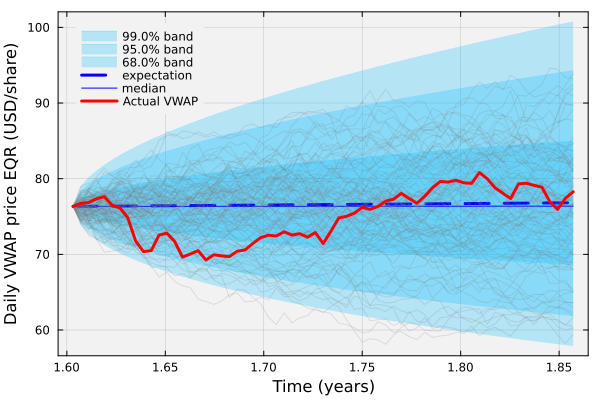

In [21]:
let
    
    # Initialize -
    time_axis = expectation_array[:,1]; # absolute time (years)
    τ = time_axis .- time_axis[1]; # elapsed time from the start of the window
    median_value = Sₒ*exp.(μ̂_g*τ); # lognormal median
    band(z) = (median_value.*exp.(-z*σ̂*sqrt.(τ)), median_value.*exp.(z*σ̂*sqrt.(τ)));

    plot();
    for level ∈ sort(gbm_band_levels; rev=true) # draw wider bands first
        z = quantile(Normal(), (1+level)/2);
        lower, upper = band(z);
        band_label = "$(round(100*level; digits=1))% band";
        plot!(time_axis, upper, fillrange=lower, c=:deepskyblue1,
            fillalpha=0.25, label=band_label, lw=0);
    end
    plot!(time_axis, expectation_array[:,2], c=:blue, lw=3, ls=:dash, label="expectation")
    plot!(time_axis, median_value, c=:blue, lw=1, label="median")

    for i ∈ 2:size(X,2) # column 1 is time, columns 2:end are the sample paths
        plot!(X[:,1], X[:,i], c=:gray50, lw=1, alpha=0.2, label="") # sample paths
    end

    plot!(time_axis, forecast_firm_data[start_index:stop_index,:volume_weighted_average_price], c=:red, lw=3, label="Actual VWAP")
    xlabel!("Time (years)", fontsize=18)
    ylabel!("Daily VWAP price $(forecast_firm_ticker) (USD/share)", fontsize=18)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topleft);
end

### Check: Did the Observed Path Stay Inside the Pointwise Band?
We check the observed prices against the widest band specified by `gbm_band_levels`. The result reports whether every price lies inside its corresponding interval. These are pointwise intervals: their stated probability does not apply to the entire path staying inside the band.

In [22]:
let
    level = maximum(gbm_band_levels); # widest configured pointwise band
    z = quantile(Normal(), (1+level)/2);
    time_axis = expectation_array[:,1];
    τ = time_axis .- time_axis[1];
    median_value = Sₒ*exp.(μ̂_g*τ);
    L = median_value.*exp.(-z*σ̂*sqrt.(τ));
    U = median_value.*exp.(z*σ̂*sqrt.(τ));
    actual = forecast_firm_data[start_index:stop_index,:volume_weighted_average_price]; # T+1 observations
    @assert length(actual) == length(L) "band and observation lengths differ"
       
    # Check whether every observed price lies inside its pointwise interval -
    success_flag = true;
    for k ∈ eachindex(actual)
        if (actual[k] < L[k]) || (actual[k] > U[k])
            success_flag = false;
            break;
        end
    end
    
    band_percent = round(100*level; digits=1);
    println("Observed $(forecast_firm_ticker) VWAP stayed inside every pointwise $(band_percent)% interval: $(success_flag)")
end

Observed EQR VWAP stayed inside every pointwise 99.0% interval: true


___

## Optional Diagnostics
The main tasks estimated the parameters and compared the fitted model with historical prices. Here, we examine the growth-rate distribution, log-price residuals, and the effect of independent perturbations on the fitted trend.

### Check: Are the Growth Rates Consistent with a Normal Distribution?
The geometric Brownian motion model assumes that equally spaced, non-overlapping growth rates are independent observations from the same normal distribution. How well does this assumption describe our selected firm's historical growth rates?

We use the Anderson–Darling statistic to measure the discrepancy between the observed growth-rate distribution and a fitted normal distribution, with particular sensitivity to the tails. Larger values indicate greater disagreement. Because we estimate the normal mean and variance from these observations, we must account for that fitting step when interpreting the statistic.

> __Parametric bootstrap:__ We compare the observed statistic with statistics from simulated normal samples:
>
> 1. Fit a normal distribution to the observed growth rates and compute the Anderson–Darling statistic.
> 2. Generate an independent sample of the same size from the fitted distribution.
> 3. Fit a new normal distribution to that sample and compute its statistic.
> 4. Repeat the simulation and fitting steps, then count how often the simulated statistic is at least as large as the observed statistic.

Refitting in every replicate makes the simulated comparison follow the procedure used for the historical data. This is the [parametric-bootstrap goodness-of-fit procedure](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.goodness_of_fit.html).

[The `fitted_normal_ad_bootstrap(...)` function](docs/fitted_normal_ad_bootstrap.md) implements this calculation using 1,000 replicates and a fixed random seed. We also compute excess kurtosis, which is zero for a normal distribution, to interpret tail behavior. The bootstrap assumes independent observations; it does not separately test independence or identify the cause of a discrepancy.

In [23]:
function fitted_normal_ad_bootstrap(x::AbstractVector{<:Real}; replicates::Int=1000, seed::Int=5660)
    fitted = fit_mle(Normal, x)
    observed = OneSampleADTest(x, fitted).A²
    rng = MersenneTwister(seed)
    exceedances = 0
    for _ ∈ 1:replicates
        sample = rand(rng, fitted, length(x))
        refitted = fit_mle(Normal, sample)
        exceedances += OneSampleADTest(sample, refitted).A² >= observed
    end
    return (A²=observed, bootstrap_pvalue=(exceedances + 1)/(replicates + 1), replicates=replicates)
end

let
    i = findfirst(==(diagnostic_firm_ticker), list_of_tickers)
    g = log_growth_array[:, i] # one-step annualized growth rates for the fixed diagnostic firm
    println("Excess kurtosis of the growth rates for $(diagnostic_firm_ticker): $(round(kurtosis(g), digits=2)) (zero for a normal distribution)")
    fitted_normal_ad_bootstrap(g)
end

Excess kurtosis of the growth rates for BK: 6.47 (zero for a normal distribution)


(A² = 31.914415420878708, bootstrap_pvalue = 0.000999000999000999, replicates = 1000)

The Anderson–Darling statistic measures disagreement with the fitted normal distribution. A small bootstrap p-value indicates that the observed discrepancy would be unusual for independent observations from a common normal distribution.

Excess kurtosis helps interpret the tails: zero is the normal reference, while positive values indicate greater weight in extreme observations. Consider it alongside the bootstrap result; the test alone does not identify the cause of a discrepancy or demonstrate volatility clustering.

Our volatility estimate $\hat{\sigma}$ summarizes growth-rate dispersion. These diagnostics help assess whether the model also describes the observed distribution.

### Log-Price Regression Residuals
In this optional diagnostic, we examine deviations from the fitted log-price trend and explain why ordinary regression uncertainty formulas do not apply.

Recall that the model's log-price errors are $\sigma W(t_j)$: they are correlated across observation times, and their variance grows with time. After fitting the intercept and slope, we compute the residuals:

$$
\mathbf r=\mathbf y-\hat{\mathbf X}\hat{\boldsymbol{\theta}}.
$$

Each residual is the difference between an observed and fitted log price. Fitting the line does not remove the dependence or make the residual variances constant, so we cannot treat these values as independent errors with a common variance.

For `diagnostic_firm_ticker`, we store the residuals in `ϵ` and fit a normal distribution, stored in `ϵₙ`, for a visual comparison.

In [24]:
ϵ, ϵₙ, A, Y = let
    firm_data = dataset[diagnostic_firm_ticker]
    T_all = all_range*Δt .- Δt
    A = [ones(maximum_number_trading_days) T_all]
    Y = log.(firm_data[!, :volume_weighted_average_price])
    θ = [θ̂_dictionary[diagnostic_firm_ticker].b, θ̂_dictionary[diagnostic_firm_ticker].m]
    residuals = Y .- A*θ
    fitted_normal = fit_mle(Normal, residuals)
    (residuals, fitted_normal, A, Y)
end

([-0.10404914823770062, -0.1004155034217531, -0.1162657713463302, -0.11638662302399405, -0.11931678193986395, -0.12941467919221772, -0.14193978029513277, -0.14425032411309946, -0.13600571938433204, -0.13794022993774435  …  0.36979011411070495, 0.34986238520163226, 0.3427174165677571, 0.35515381345073704, 0.3532928412308127, 0.3613103759760916, 0.36454146843857105, 0.3556070347672873, 0.3478476422467214, 0.34669453039985987], Normal{Float64}(μ=2.198779246456761e-17, σ=0.15273034150917295), [1.0 0.0; 1.0 0.003968253968253968; … ; 1.0 10.972222222222221; 1.0 10.976190476190474], [3.557212037491987, 3.5609665339855985, 3.5452371177386848, 3.5452371177386848, 3.5424278105004783, 3.5324507649257884, 3.5200465155005367, 3.517856823360234, 3.5262222797666647, 3.524408620890916  …  4.364239375159062, 4.344432497927652, 4.337408380971441, 4.349965629532084, 4.348225508989824, 4.356363895412766, 4.359715839552909, 4.350902257559289, 4.343263716716387, 4.342231456547189])

The plot compares the residual density with the fitted normal curve. Look for differences in symmetry, concentration, and tails; this visual comparison does not assess dependence across observation times.

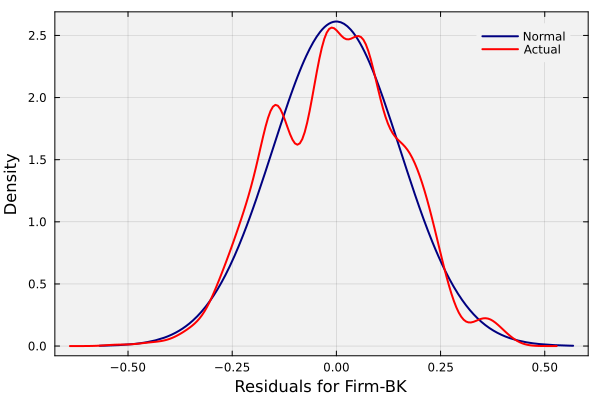

In [25]:
let 
    
    plot(ϵₙ, label="Normal", c=:navyblue,lw=2)
    density!(ϵ, normalize=true, xlabel="Residuals for Firm-$(diagnostic_firm_ticker)", 
        ylabel="Density", label="Actual", c=:red,lw=2)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

end

#### Anderson–Darling Statistic for Dependent Residuals
We use [the `OneSampleADTest` type](https://juliastats.org/HypothesisTests.jl/stable/nonparametric/) to compute the Anderson–Darling statistic for the residuals and their fitted normal distribution.

> __Interpretation:__ The usual p-value assumes independent observations from a fully specified distribution. Our residuals are dependent, and the normal parameters were estimated from them. We therefore report only the statistic as a descriptive measure of disagreement. The independent-sample bootstrap used for growth rates would not account for this residual dependence.

In [26]:
residual_ad = OneSampleADTest(ϵ, ϵₙ);
(A² = residual_ad.A²,)

(A² = 3.518629525654343,)

The statistic complements the density plot; it does not establish whether the geometric Brownian motion model is appropriate. Next, we examine how independent perturbations affect the fitted trend and why that calculation does not describe uncertainty under the Brownian error model.

### Effect of Independent Perturbations on the Fitted Trend
How would the fitted trend change if we treated the errors as independent normal observations? We explore this assumption by drawing a perturbation for each log price from the fitted residual distribution `ϵₙ`, adding these perturbations to `Y`, and refitting the intercept and slope.

We repeat this calculation `number_of_trend_simulations` times, as set in the Constants section, and store the fitted log-price trajectories in the columns of `error_simulation_array`. Exponentiating these values gives the corresponding fitted price curves.

This exercise illustrates how independent perturbations affect the fitted line. Because the Brownian errors are dependent, the resulting spread does not provide calibrated uncertainty intervals for $\mu_g$ or prediction bands for future prices.

In [27]:
error_simulation_array = let
    N = number_of_trend_simulations
    rng = MersenneTwister(5661); # reproducible residual-resampling demonstration
    
    error_simulation_array = Array{Float64,2}(undef,maximum_number_trading_days,N);
    for i ∈ 1:N
        error = rand(rng, ϵₙ, maximum_number_trading_days)
        θᵢ = A \ (Y + error) # refit the perturbed log-price observations
        Ŷᵢ = A*θᵢ
        for k ∈ 1:maximum_number_trading_days
            error_simulation_array[k,i] =  Ŷᵢ[k]
        end
    end

    error_simulation_array;
end

2767×1000 Matrix{Float64}:
 3.65987  3.66477  3.65811  3.65573  …  3.66677  3.65531  3.6726   3.66584
 3.65999  3.66489  3.65823  3.65586     3.66689  3.65543  3.67271  3.66596
 3.6601   3.66501  3.65834  3.65598     3.66701  3.65555  3.67282  3.66608
 3.66022  3.66513  3.65846  3.6561      3.66713  3.65567  3.67294  3.6662
 3.66034  3.66525  3.65858  3.65623     3.66725  3.6558   3.67305  3.66632
 3.66046  3.66537  3.6587   3.65635  …  3.66737  3.65592  3.67317  3.66644
 3.66058  3.66549  3.65882  3.65647     3.66749  3.65604  3.67328  3.66656
 3.6607   3.66561  3.65894  3.65659     3.66761  3.65616  3.67339  3.66669
 3.66082  3.66572  3.65906  3.65672     3.66773  3.65629  3.67351  3.66681
 3.66094  3.66584  3.65918  3.65684     3.66785  3.65641  3.67362  3.66693
 3.66106  3.66596  3.6593   3.65696  …  3.66797  3.65653  3.67373  3.66705
 3.66118  3.66608  3.65942  3.65709     3.66809  3.65665  3.67385  3.66717
 3.6613   3.6662   3.65954  3.65721     3.66821  3.65678  3.67396  3.66729

The plot compares the observed prices in blue with the fitted trend in red. The gray region contains the central fraction of perturbed fitted prices specified by `trend_band_fraction`, calculated separately at each observation time.

This region shows variation in the fitted trend under independent perturbations. It does not describe the range of future price fluctuations; we constructed the model's price-distribution bands in Task 3.

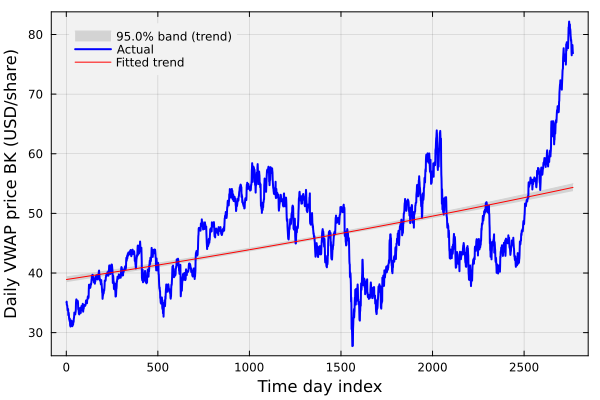

In [28]:
let
    
    θ = [
        θ̂_dictionary[diagnostic_firm_ticker].b, # intercept
        θ̂_dictionary[diagnostic_firm_ticker].m # slope
    ];
    
    Ŷ = A*θ;
    P = exp.(error_simulation_array); # fitted price trajectories, one per column
    tail_probability = (1.0 - trend_band_fraction)/2; # equal probability in each tail
    lower_value = [quantile(P[k,:], tail_probability) for k ∈ 1:size(P,1)];
    upper_value = [quantile(P[k,:], 1.0 - tail_probability) for k ∈ 1:size(P,1)];
    band_label = "$(round(100*trend_band_fraction; digits=1))% band (trend)";
    plot(upper_value, fillrange=lower_value, label=band_label, c=:lightgray)
    plot!(exp.(Y),c=:blue,lw=2, label="Actual")
    plot!(exp.(Ŷ),c=:red,lw=1, label="Fitted trend")
    xlabel!("Time day index", fontsize=18);
    ylabel!("Daily VWAP price $(diagnostic_firm_ticker) (USD/share)", fontsize=18)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

__Why do the fitted price curves bend?__ Each simulated fit is a straight line in log-price space. Exponentiating it produces a price curve whose shape depends on the fitted intercept and slope. Variation in these parameters also changes the spread between curves over time. The plot below displays a subset of the perturbed fits alongside the original fitted trend and observed prices.

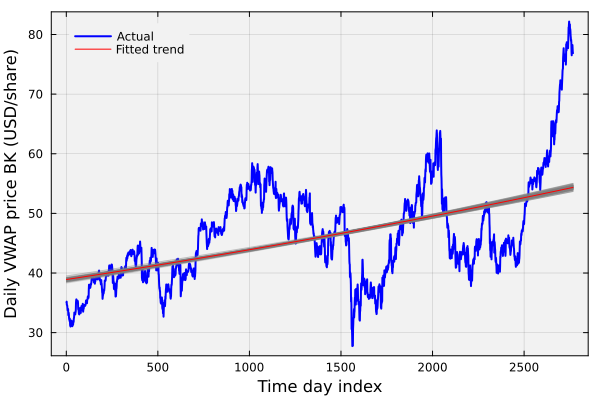

In [29]:
let

    N = number_of_trend_simulations;
    θ = [
        θ̂_dictionary[diagnostic_firm_ticker].b, # intercept
        θ̂_dictionary[diagnostic_firm_ticker].m # slope
    ];


    Yₘ = A*θ;
    skip = 10;
    plot(exp.(Y),c=:blue,lw=2, label="Actual")
    mean_value = mean(exp.(error_simulation_array),dims=2);
    for i ∈ 1:skip:N
        Ŷ = error_simulation_array[:,i];
        plot!(exp.(Ŷ), c=:gray50, label="", alpha=0.25)
    end
    current()
    plot!(exp.(Yₘ),c=:red,lw=1, label="Fitted trend")
    xlabel!("Time day index", fontsize=18);
    ylabel!("Daily VWAP price $(diagnostic_firm_ticker) (USD/share)", fontsize=18)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

___

## Summary
In this example, we estimated a single-asset geometric Brownian motion model from historical prices, examined its assumptions, and compared its fitted price distribution with observed data.

> __Key Takeaways:__
>
> * **Parameter estimation:** We estimated mean growth from log-price regression and one-step growth rates, and volatility from growth-rate dispersion. Adding the half-variance correction converted mean growth into the arithmetic drift needed for simulation.
> * **Model diagnostics:** We used a fitted-normal bootstrap to examine growth rates and studied the dependence of log-price residuals. This helped us distinguish the growth-rate diagnostic from ordinary regression uncertainty calculations.
> * **Price distributions:** We generated sample paths and calculated the model's mean, variance, and pointwise lognormal intervals. Comparing these with historical prices connected the fitted parameters to the model's price distribution and clarified the difference between pointwise intervals and coverage of an entire path.

Next, we'll use the fitted model to calculate the probability that a trade exceeds a target discounted return over a specified holding period.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products, or any investment or trading advice or strategy, is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
